In [ ]:
import duckdb
import matplotlib.pyplot as plt

In [ ]:
# verbinding met de data base
con = duckdb.connect("C:/Users/stijn/OneDrive/Documenten/GitHub/DataEngineering_M_S/dvdrental/dvdrental.duckdb", read_only=True)

In [ ]:

# sql query 
df = con.execute("SELECT * FROM Fact_omzet_stad").df()

               city_name  totale_omzet
0            Saint-Denis        211.55
1             Cape Coral        208.58
2    Santa Brbara dOeste        194.61
3              Apeldoorn        191.62
4              Molodetno        189.60
..                   ...           ...
592                Enshi         49.88
593               Tafuna         47.85
594          Tallahassee         37.87
595               Fuzhou         32.90
596            Bydgoszcz         27.93

[597 rows x 2 columns]


In [ ]:
con.close()

In [ ]:

print(df)

### Top 10 steden met de meeste opbrengst

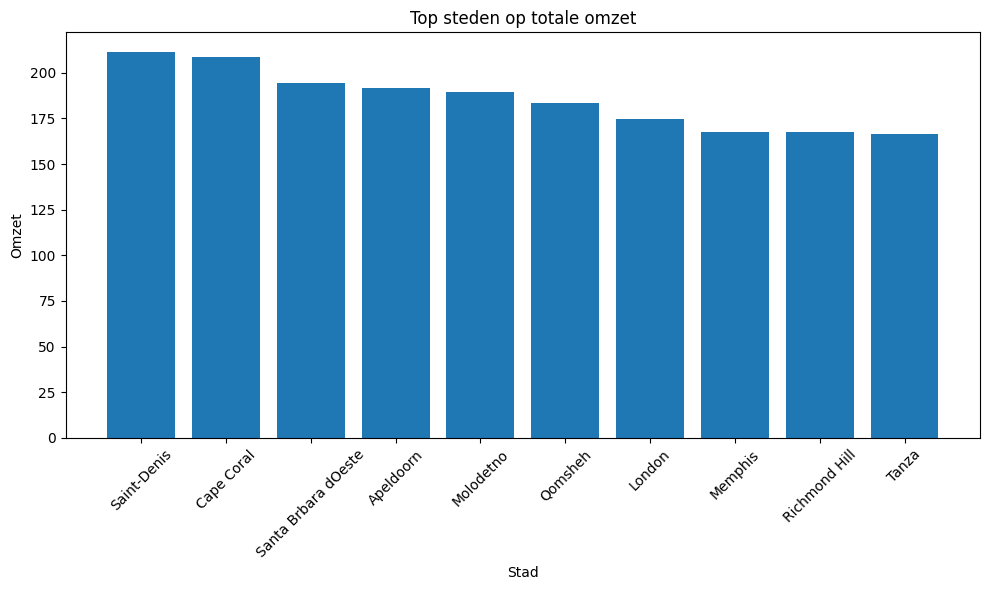

Saint-Denis: 0.35%
Cape Coral: 0.34%
Santa Brbara dOeste: 0.32%
Apeldoorn: 0.31%
Molodetno: 0.31%
Qomsheh: 0.30%
London: 0.28%
Memphis: 0.27%
Richmond Hill: 0.27%
Tanza: 0.27%


In [70]:
aantal = 10
top = df.sort_values('totale_omzet', ascending=False).head(aantal)

total = df['totale_omzet'].sum()
top['percentage'] = top['totale_omzet'] / total * 100

plt.figure(figsize=(10, 6))
plt.bar(top['city_name'], top['totale_omzet'])

plt.title('Top steden op totale omzet')
plt.xlabel('Stad')
plt.ylabel('Omzet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for _, row in top.iterrows():
    print(f"{row['city_name']}: {row['percentage']:.2f}%")

### Top 10 steden met de minste opbrengst

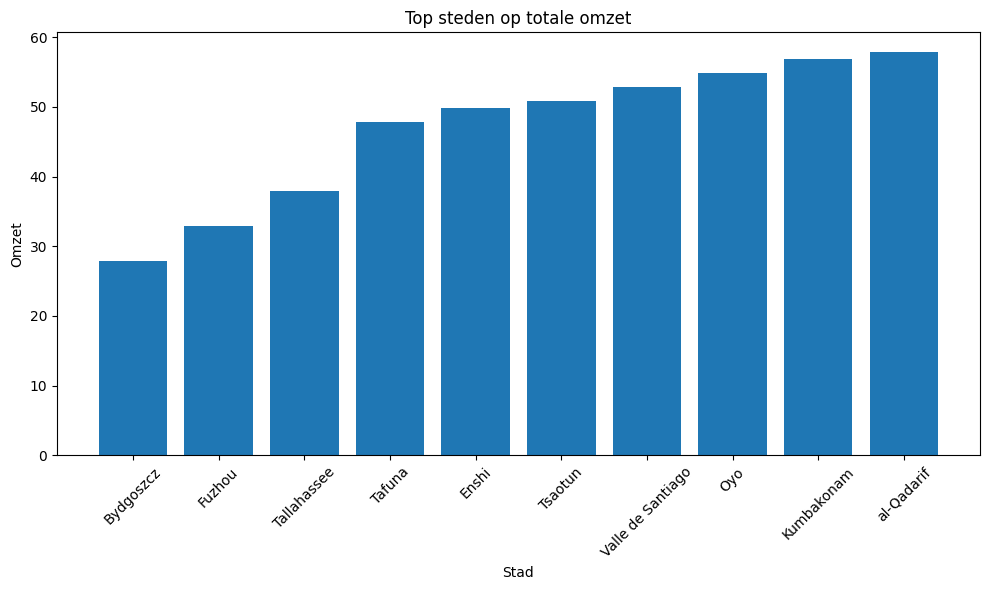

Bydgoszcz: 0.05%
Fuzhou: 0.05%
Tallahassee: 0.06%
Tafuna: 0.08%
Enshi: 0.08%
Tsaotun: 0.08%
Valle de Santiago: 0.09%
Oyo: 0.09%
Kumbakonam: 0.09%
al-Qadarif: 0.09%


In [71]:
aantal = 10
top = df.sort_values('totale_omzet', ascending=True).head(aantal)

total = df['totale_omzet'].sum()
top['percentage'] = top['totale_omzet'] / total * 100

plt.figure(figsize=(10, 6))
plt.bar(top['city_name'], top['totale_omzet'])

plt.title('Top steden op totale omzet')
plt.xlabel('Stad')
plt.ylabel('Omzet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for _, row in top.iterrows():
    print(f"{row['city_name']}: {row['percentage']:.2f}%")

### De verdeling van de omzet per stad

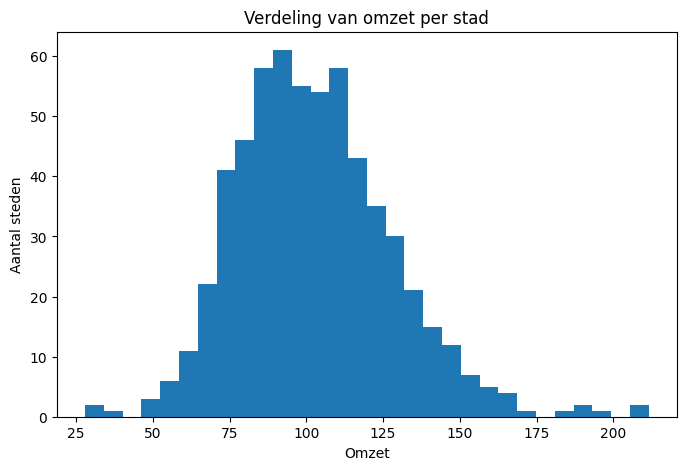

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df['totale_omzet'], bins=30)
plt.title('Verdeling van omzet per stad')
plt.xlabel('Omzet')
plt.ylabel('Aantal steden')
plt.show()